# Misc

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os, sys
from scipy.stats import rankdata
from datetime import datetime

notebook_dir = os.getcwd()  # Gets test folder path
project_dir = os.path.join(os.path.dirname(notebook_dir), 'Result', 'Benchmark - raw collection')  
os.chdir(project_dir)
os.getcwd()

'd:\\Jacky\\MATLAB\\OptimalPlacement\\Result and analysis\\Result\\Benchmark - raw collection'

In [2]:
def R_method(Pareto_font, rank_obj):
    Pareto_font = np.asarray(Pareto_font, dtype=float)
    rank_obj = np.asarray(rank_obj, dtype=float)

    numSol, numVar = Pareto_font.shape

    # Rank variables (MATLAB tiedrank)
    rankVar = np.zeros_like(Pareto_font)
    for j in range(numVar):
        rankVar[:, j] = rankdata(Pareto_font[:, j], method="average")

    # Variable weight set
    numRank = np.arange(1, numSol + 1)
    denom_sol = sum(1 / np.sum(1 / numRank[:j]) for j in range(1, numSol + 1))
    weightsVar_set = np.array([
        (1 / np.sum(1 / numRank[:j])) / denom_sol
        for j in range(1, numSol + 1)
    ])

    # Objective weight set
    numRankObj = np.arange(1, numVar + 1)
    denom_obj = sum(1 / np.sum(1 / numRankObj[:j]) for j in range(1, numVar + 1))
    weightsObj_set = np.array([
        (1 / np.sum(1 / numRankObj[:j])) / denom_obj
        for j in range(1, numVar + 1)
    ])

    # Assign variable weights
    weightsVar = np.zeros_like(Pareto_font)
    for i in range(numSol):
        for j in range(numVar):
            weightsVar[i, j] = weightsVar_set[int(rankVar[i, j]) - 1]

    # Assign objective weights (MATLAB bug preserved)
    weightsObj = np.zeros(numVar)
    for j in range(numVar):
        if not rank_obj[j].is_integer():
            weightsObj[j] = weightsObj_set[0] + weightsObj_set[1]
        else:
            weightsObj[j] = weightsObj_set[int(rank_obj[j]) - 1]

    # Composite score
    composite_score = weightsVar @ weightsObj

    # FINAL RANK — NO INVERSION
    finalRank = rankdata(composite_score, method="average")

    sorted_idx = np.argsort(finalRank)[::-1]
    top5_loc = sorted_idx[:5]

    return top5_loc, finalRank, composite_score


# Raw data processing

In [3]:
# Aggregate results from all PCs
pos_all = []
obj_all = []
cwd = os.getcwd()
folders = [d for d in os.listdir(cwd) if os.path.isdir(os.path.join(cwd, d))]
for folder in folders:
    folder_path = os.path.join(cwd, folder)
    files = [f for f in os.listdir(folder_path) if f.endswith('.xlsx')]
    print(f"Folder: {folder} ({len(files)} files)")
    print(f"Files: {files}")
    for file in files:
        file_path = os.path.join(folder_path, file)
        pos = pd.read_excel(file_path, sheet_name="Sheet1", header=None).to_numpy()
        obj = pd.read_excel(file_path, sheet_name="Sheet2", header=None).to_numpy()
        assert pos.shape[0] == obj.shape[0], f"Position and Objective rows do not match in file: {file}!"
        pos_all.append(pos)
        obj_all.append(obj)
    

Folder: 1 (4 files)
Files: ['benchmark result 1.xlsx', 'benchmark result 2.xlsx', 'benchmark result 3.xlsx', 'benchmark result middle.xlsx']
Folder: 2 (15 files)
Files: ['benchmark result 1.xlsx', 'benchmark result 10.xlsx', 'benchmark result 11.xlsx', 'benchmark result 12.xlsx', 'benchmark result 13.xlsx', 'benchmark result 2.xlsx', 'benchmark result 3.xlsx', 'benchmark result 4.xlsx', 'benchmark result 5.xlsx', 'benchmark result 6.xlsx', 'benchmark result 7.xlsx', 'benchmark result 8.xlsx', 'benchmark result 9.xlsx', 'benchmark result middle.xlsx', 'benchmark result.xlsx']
Folder: 3 (33 files)
Files: ['benchmark result 1.xlsx', 'benchmark result 10.xlsx', 'benchmark result 11.xlsx', 'benchmark result 12.xlsx', 'benchmark result 13.xlsx', 'benchmark result 14.xlsx', 'benchmark result 15.xlsx', 'benchmark result 16.xlsx', 'benchmark result 17.xlsx', 'benchmark result 18.xlsx', 'benchmark result 19.xlsx', 'benchmark result 2.xlsx', 'benchmark result 20.xlsx', 'benchmark result 21.xlsx',

In [4]:
pos_all = np.vstack(pos_all)
obj_all = np.vstack(obj_all)

mask = obj_all[:,0] != 100000
obj = obj_all[mask]
position = pos_all[mask]

np.savez('benchmark_all.npz', pos_all=position, obj_all=obj)

pos_all.shape, obj_all.shape, position.shape, obj.shape

((1056046, 9), (1056046, 3), (1056040, 9), (1056040, 3))

# Ranking Pareto font and search space

In [4]:
# SANITY CHECK R-Method
# =============================
Pareto_font = np.array([
    [1, 10, 100],
    [2, 20,  90],
    [3, 30,  80],
    [4, 40,  70],
    [6, 50,  60],
    [5, 50,  60]
])

rank_obj = np.array([1, 2, 3])

top5, final_rank, score = R_method(Pareto_font, rank_obj)

print("\n--- PYTHON RESULTS ---")
print("Top 5 locations (0-based):", top5)
print("Top 5 locations (MATLAB style):", top5 + 1)
print("Final Rank:", final_rank)
print("Composite Score (Top 5):", score)



--- PYTHON RESULTS ---
Top 5 locations (0-based): [0 1 5 4 2]
Top 5 locations (MATLAB style): [1 2 6 5 3]
Final Rank: [6. 5. 2. 1. 3. 4.]
Composite Score (Top 5): [0.24138201 0.17247903 0.14959838 0.14022208 0.15913963 0.16294605]


In [15]:
data = np.load('benchmark_all.npz')
pos_all = data['pos_all']
obj_all = data['obj_all']

pos_all.shape, obj_all.shape

((1056040, 9), (1056040, 3))

In [6]:
# x = obj_all[:, 0] * 1e3        # Power Loss
# y = obj_all[:, 1] / 1e5        # CES Investment
# z = obj_all[:, 2]
# fontttt = 10

# fig = plt.figure(constrained_layout=True)
# ax = fig.add_subplot(111, projection='3d')
# ax.scatter(x, y, z, c=pos_all[:,1], cmap='viridis', alpha=0.7)
# ax.set_xlabel(r'Power Loss ($\times 10^{-3}$ kW)', fontsize=fontttt)
# ax.set_ylabel(r'CES Investment ($\times 10^{5}$ RM)', fontsize=fontttt)
# ax.set_zlabel('Average Cost of Prosumer (RM)', fontsize=fontttt)

# # Set camera angle
# ax.view_init(elev=30, azim=30)    # elev = vertical angle, azim = rotation (degrees)
# ax.dist = 10                      # camera distance (optional)

# # ax.set_title('Pareto Front in Objective Space', fontsize=14)
# ax.set_box_aspect(aspect=None, zoom=0.85)
# plt.savefig(f"benchmark sol search space.png", format = "png", bbox_inches='tight', dpi = 300)
# plt.show()

In [ ]:
n_old = obj_all.shape[0]   # number of rows BEFORE append

obj_all = np.vstack([
    obj_all,
    [5.56, 682937.76, 71.08],
    [5.35, 879673.67, 71.24],
    [5.12, 559160.47, 71.69]
])

pos_all = np.vstack([
    pos_all,
    [4, 2, 25, 33, 19, 108.78, 81, 223.37, 269.79],
    [3, 20, 33, 22, 0, 309, 261.67, 309, 0],
    [2, 19, 33, 0, 0, 283.52, 275.64, 0, 0]
])

new_indices = np.arange(n_old, n_old + 3)

rank_obj = np.array([1, 2.5, 2.5])

top5, final_rank, score = R_method(obj_all, rank_obj)

sorted_indices = np.argsort(final_rank)[::-1]

# Apply the sorted indices to obj_all and pos_all
sorted_obj_all = obj_all[sorted_indices]
sorted_pos_all = pos_all[sorted_indices]
sorted_score = score[sorted_indices]

# Save the sorted arrays to a .npz file
np.savez('benchmark_ranked_MOO.npz', obj_all=sorted_obj_all, pos_all=sorted_pos_all, score=sorted_score, final_rank=final_rank)

# Print confirmation
print("Top 5 locations (0-based):", top5)
print("Top 5 locations (MATLAB style):", top5 + 1)
print("Composite Score (Top 5):", sorted_score[:5])

KeyboardInterrupt: 

Top 5 locations (0-based): [427420 400062 327476 327596 327716] <br>
Top 5 locations (MATLAB style): [427421 400063 327477 327597 327717] <br>
Composite Score (Top 5): [1.06171759e-05 7.48938372e-06 7.45160750e-06 7.43821614e-06 7.43267392e-06]

In [34]:
new_ranks = {}

for idx in new_indices:
    rank_position = np.where(sorted_indices == idx)[0][0] + 1  # 1-based rank
    new_ranks[idx] = rank_position
    
for i, idx in enumerate(new_indices):
    print(f"New solution {i+1}:")
    print(f"  Objectives = {obj_all[idx]}")
    print(f"  Composite score = {sorted_score[new_ranks[idx]-1]}")
    print(f"  Rank = {new_ranks[idx]} / {len(sorted_score)}\n")

New solution 1:
  Objectives = [5.5600000e+00 6.8293776e+05 7.1080000e+01]
  Composite score = 2.3275694098997343e-06
  Rank = 2855 / 1056043

New solution 2:
  Objectives = [5.3500000e+00 8.7967367e+05 7.1240000e+01]
  Composite score = 2.110829403663431e-06
  Rank = 15536 / 1056043

New solution 3:
  Objectives = [5.1200000e+00 5.5916047e+05 7.1690000e+01]
  Composite score = 1.8865918700520053e-06
  Rank = 232893 / 1056043



In [29]:
np.where(np.argsort(final_rank)[::-1] == 1056042)

(array([232892]),)

In [31]:
# Load and check the saved file (for verification)
data = np.load('benchmark_ranked_MOO.npz')
sorted_pos_all = data['pos_all']
sorted_obj_all_sorted = data['obj_all']
sorted_score = data['score']
final_rank = data['final_rank']

# Computational time

In [3]:
# Aggregate times from all PCs (benchmark processing)
from datetime import datetime, timedelta
durations = []
runtime = {}
cwd = os.getcwd()
folders = [d for d in os.listdir(cwd) if os.path.isdir(os.path.join(cwd, d))]
for folder in folders:
    if folder == 'opt_result':
        continue
    times = []
    folder_path = os.path.join(cwd, folder)
    files = [f for f in os.listdir(folder_path) if f.endswith('.xlsx')]
    print(f"Folder: {folder} ({len(files)} files)")
    # print(f"Files: {files}")
    for file in files:
        file_path = os.path.join(folder_path, file)
        time = datetime.fromtimestamp(os.path.getmtime(file_path)) if datetime.fromtimestamp(os.path.getmtime(file_path)).month != 12 else datetime(2025, 8, 18, 14, 40, 0)
        times.append(time)
    times.sort()
    # print(f"Modification times (sorted): {times}")
    durations = [(times[i+1] - times[i]) for i in range(len(times)-1)] if durations else [(times[i+1] - times[i]) for i in range(len(times)-1)]
    # for i, d in enumerate(durations):
    #     print(f"Runtime {i+1} → {i+2}: {d}")
    runtime[folder] = sum(durations, start=durations[0]*0)
    print(f"Total runtime for folder {folder}: {sum(durations, start=durations[0]*0)}\n")

grand_total = sum(runtime.values(), start=timedelta(0))
print("Total runtimes:" , grand_total)

total_days_benchmark = grand_total.total_seconds() / (24 * 3600)
total_hours_benchmark = grand_total.total_seconds() / 3600

print(f"Grand total runtime ≈ {total_days_benchmark:.1f} days")
print(f"Grand total runtime ≈ {total_hours_benchmark:.1f} hours")

Folder: 1 (4 files)
Total runtime for folder 1: 14 days, 4:35:18

Folder: 2 (15 files)
Total runtime for folder 2: 40 days, 3:38:12

Folder: 3 (33 files)
Total runtime for folder 3: 180 days, 9:26:34.568640

Total runtimes: 234 days, 17:40:04.568640
Grand total runtime ≈ 234.7 days
Grand total runtime ≈ 5633.7 hours


In [8]:
"""
candidate_count.py
==================
Computes the discrete search space size (number of candidate solutions)
for the 33-bus and 69-bus CES placement problems, and estimates the
exhaustive search (ES) runtime for the 69-bus case based on the
measured 33-bus ES runtime.

Bounds taken directly from Table I of the paper:
  33-bus: num_units [1,4],  locations [2,33],  capacity [81,309]  → 9  variables
  69-bus: num_units [1,8],  locations [2,69],  capacity [81,309]  → 17 variables

NOTE: The MATLAB optimiser code uses capacity bounds [76, 304] instead
of [81, 309].  Both ranges span 229 discrete values, so the candidate
count is identical either way.  The script uses [81, 309] (Table I).
"""

from math import prod

# ── 33-bus ────────────────────────────────────────────────────────────────────
#  Structure: 1 (num_units) + 4 (locations) + 4 (capacities) = 9 variables
LB_33 = [1,  2,  2,  2,  2,  81,  81,  81,  81]
UB_33 = [4, 33, 33, 33, 33, 309, 309, 309, 309]

# ── 69-bus ────────────────────────────────────────────────────────────────────
#  Structure: 1 (num_units) + 8 (locations) + 8 (capacities) = 17 variables
LB_69 = [1,  2,  2,  2,  2,  2,  2,  2,  2,  81,  81,  81,  81,  81,  81,  81,  81]
UB_69 = [8, 69, 69, 69, 69, 69, 69, 69, 69, 309, 309, 309, 309, 309, 309, 309, 309]

# ── Candidate count per variable and total ────────────────────────────────────
n_per_var_33 = [UB_33[i] - LB_33[i] + 1 for i in range(len(LB_33))]
n_per_var_69 = [UB_69[i] - LB_69[i] + 1 for i in range(len(LB_69))]

N_33 = prod(n_per_var_33)
N_69 = prod(n_per_var_69)

# ── Scale factor and time estimate ────────────────────────────────────────────
T_33_hours = 5_633.67          # measured ES runtime for 33-bus
scale      = N_69 / N_33
T_69_est   = T_33_hours * scale

# ── Print breakdown ───────────────────────────────────────────────────────────
SEP = "=" * 62

print(SEP)
print("33-BUS SEARCH SPACE")
print(f"  Variables      : {len(LB_33)}  "
      f"(1 num_units + 4 locations + 4 capacities)")
print(f"  Choices/var    : {n_per_var_33}")
print(f"  Formula        : "
      f"{n_per_var_33[0]} x "
      f"{n_per_var_33[1]}^4 x "
      f"{n_per_var_33[5]}^4")
print(f"  N_33           : {N_33:.4e} candidates")

print()
print("69-BUS SEARCH SPACE")
print(f"  Variables      : {len(LB_69)}  "
      f"(1 num_units + 8 locations + 8 capacities)")
print(f"  Choices/var    : {n_per_var_69}")
print(f"  Formula        : "
      f"{n_per_var_69[0]} x "
      f"{n_per_var_69[1]}^8 x "
      f"{n_per_var_69[9]}^8")
print(f"  N_69           : {N_69:.4e} candidates")

print()
print("SCALE FACTOR")
print(f"  N_69 / N_33    : {scale:.4e}")

print()
print("ESTIMATED ES RUNTIME — 69-BUS")
print(f"  T_33 (measured): {T_33_hours:,.2f} hours")
print(f"  T_69 = T_33 x (N_69 / N_33)")
print(f"       = {T_33_hours:,.2f} x {scale:.4e}")
print(f"       = {T_69_est:.4e} hours")
print(f"       = {T_69_est / 8_760:.4e} years")
print(f"       = {T_69_est / 8_760 / 1e9:.4e} billion years")
print(f"  (Age of universe ~ 1.38e10 years — "
      f"this is {T_69_est/8_760/1.38e10:.2e}x larger)")

print(SEP)

33-BUS SEARCH SPACE
  Variables      : 9  (1 num_units + 4 locations + 4 capacities)
  Choices/var    : [4, 32, 32, 32, 32, 229, 229, 229, 229]
  Formula        : 4 x 32^4 x 229^4
  N_33           : 1.1535e+16 candidates

69-BUS SEARCH SPACE
  Variables      : 17  (1 num_units + 8 locations + 8 capacities)
  Choices/var    : [8, 68, 68, 68, 68, 68, 68, 68, 68, 229, 229, 229, 229, 229, 229, 229, 229]
  Formula        : 8 x 68^8 x 229^8
  N_69           : 2.7660e+34 candidates

SCALE FACTOR
  N_69 / N_33    : 2.3980e+18

ESTIMATED ES RUNTIME — 69-BUS
  T_33 (measured): 5,633.67 hours
  T_69 = T_33 x (N_69 / N_33)
       = 5,633.67 x 2.3980e+18
       = 1.3509e+22 hours
       = 1.5422e+18 years
       = 1.5422e+09 billion years
  (Age of universe ~ 1.38e10 years — this is 1.12e+08x larger)


In [20]:
# Aggregate times from all PCs (MOOs processing)
from datetime import datetime
durations = []
moo_rows = []
moo_rows.append({
        "Method": 'Exhaustive Search',
        "Runtime (hours)": total_hours_benchmark,
        "Runtime (minutes)": total_hours_benchmark * 60,
        "Speed-up vs Benchmark (×)": '-'
    })

cwd = r"D:\Jacky\MATLAB\OptimalPlacement\Result\Data\Computational time"
folders = [d for d in os.listdir(cwd) if os.path.isdir(os.path.join(cwd, d))]
for folder in folders:
    times = []
    folder_path = os.path.join(cwd, folder)
    files = [f for f in os.listdir(folder_path) if f.endswith('.xlsx')]
    print(f"Folder: {folder} ({len(files)} files)")
    # print(f"Files: {files}")
    for file in files:
        file_path = os.path.join(folder_path, file)
        time = datetime.fromtimestamp(os.path.getmtime(file_path)) if datetime.fromtimestamp(os.path.getmtime(file_path)).month != 12 else datetime(2025, 8, 18, 14, 40, 0)
        times.append(time)
    times.sort()
    # print(f"Modification times (sorted): {times}")
    durations = [(times[i+1] - times[i]) for i in range(len(times)-1)] if durations else [(times[i+1] - times[i]) for i in range(len(times)-1)]
    # for i, d in enumerate(durations):
    #     print(f"Runtime {i+1} → {i+2}: {d}")
    # runtime += sum(durations, start=durations[0]*0)
    print(f"Total runtime for folder {folder}: {sum(durations, start=durations[0]*0)}")
    grand_total = sum(durations, start=durations[0]*0)
    total_days = grand_total.total_seconds() / (24 * 3600)
    total_hours = grand_total.total_seconds() / 3600

    print(f"Grand total runtime for folder {folder} ≈ {total_days:.1f} days")
    print(f"Grand total runtime for folder {folder} ≈ {total_hours:.1f} hours\n")
    print(f"Acceleration factor ≈ {total_hours_benchmark / total_hours:.1f}x\n")

    moo_rows.append({
        "Method": folder,
        "Runtime (hours)": total_hours,
        "Runtime (minutes)": total_hours * 60,
        "Speed-up vs Benchmark (×)": total_hours_benchmark / total_hours
    })

moo_rows[1], moo_rows[2], moo_rows[3] = moo_rows[3], moo_rows[1], moo_rows[2]
moo_df = pd.DataFrame(moo_rows)
moo_df


Folder: MOLA (10 files)
Total runtime for folder MOLA: 1 day, 1:04:21.882239
Grand total runtime for folder MOLA ≈ 1.0 days
Grand total runtime for folder MOLA ≈ 25.1 hours

Acceleration factor ≈ 224.7x

Folder: MOMSA (10 files)
Total runtime for folder MOMSA: 21:47:45.792981
Grand total runtime for folder MOMSA ≈ 0.9 days
Grand total runtime for folder MOMSA ≈ 21.8 hours

Acceleration factor ≈ 258.5x

Folder: MOPSO (10 files)
Total runtime for folder MOPSO: 13:46:21.289744
Grand total runtime for folder MOPSO ≈ 0.6 days
Grand total runtime for folder MOPSO ≈ 13.8 hours

Acceleration factor ≈ 409.0x



,Method,Runtime (hours),Runtime (minutes),Speed-up vs Benchmark (×)
0,Exhaustive Search,5633.667936,338020.076144,-
1,MOPSO,13.772580,826.354829,409.049556
2,MOLA,25.072745,1504.364704,224.692905
3,MOMSA,21.796054,1307.763216,258.471925


In [4]:
import os
import pandas as pd
from datetime import datetime

# ── Configuration ────────────────────────────────────────────────────────────
# All result files live in ONE flat folder (not separated into subfolders).
# Files are distinguished by their name prefix, e.g.:
#   "MOMSA result 1.xlsx", "MOLA result 1.xlsx", "MOPSO result 1.xlsx"
# Edit cwd and method_prefixes to match your actual filenames.

cwd = r"D:\Jacky\Data Output\CES size and loc\69bus_ptdf\raw\archieve"

# Map display name → filename prefix to match against
method_prefixes = {
    "MOMSA": "MOMSA",
    "MOLA" : "MOLA",
    "MOPSO": "MOPSO",
}

# Sentinel: files modified in December are assumed to be from a specific
# fixed date (handles clock/timezone artefact on some PCs)
DEC_FALLBACK = datetime(2025, 8, 18, 14, 40, 0)

# ── Build rows ───────────────────────────────────────────────────────────────
moo_rows = []

# Row 0 — Exhaustive Search (pre-computed elsewhere)
# moo_rows.append({
#     "Method"                  : "Exhaustive Search",
#     "Runtime (hours)"         : total_hours_benchmark,
#     "Runtime (minutes)"       : total_hours_benchmark * 60,
#     "Speed-up vs Benchmark (×)": "-",
# })

# Get all xlsx files in the flat folder once
all_files = [
    f for f in os.listdir(cwd)
    if f.endswith(".xlsx") and os.path.isfile(os.path.join(cwd, f))
]
print(f"Total xlsx files found: {len(all_files)}\n")

for method_name, prefix in method_prefixes.items():
    # Filter files whose name starts with the method prefix (case-insensitive)
    matched = [
        f for f in all_files
        if f.lower().startswith(prefix.lower())
    ]
    print(f"Method: {method_name}  prefix='{prefix}'  ({len(matched)} files matched)")

    if len(matched) < 2:
        print(f"  ⚠ Need at least 2 files to compute a duration — skipping.\n")
        continue

    # Extract modification times, apply December fallback
    times = []
    for f in matched:
        mtime = datetime.fromtimestamp(os.path.getmtime(os.path.join(cwd, f)))
        if mtime.month == 12:
            mtime = DEC_FALLBACK
        times.append(mtime)
    times.sort()

    # Consecutive-file durations
    durations = [times[i+1] - times[i] for i in range(len(times) - 1)]
    grand_total  = sum(durations, start=durations[0] * 0)
    total_hours  = grand_total.total_seconds() / 3600
    total_days   = grand_total.total_seconds() / (24 * 3600)
    # acceleration = total_hours_benchmark / total_hours if total_hours > 0 else float("inf")

    print(f"  Grand total ≈ {total_days:.1f} days  /  {total_hours:.2f} hours")
    # print(f"  Acceleration factor ≈ {acceleration:.2f}×\n")

    moo_rows.append({
        "Method"                  : method_name,
        "Runtime (hours)"         : round(total_hours, 2),
        "Runtime (minutes)"       : round(total_hours * 60, 2),
        # "Speed-up vs Benchmark (×)": round(acceleration, 2),
    })

# ── Reorder rows: ES first, then MOPSO, MOLA, MOMSA (adjust as needed) ──────
# Current order after loop: ES(0), MOMSA(1), MOLA(2), MOPSO(3)
# Desired order:            ES(0), MOPSO(1), MOLA(2), MOMSA(3) — fastest first
if len(moo_rows) == 4:
    moo_rows[1], moo_rows[2], moo_rows[3] = moo_rows[3], moo_rows[2], moo_rows[1]

moo_df = pd.DataFrame(moo_rows)
moo_df

Total xlsx files found: 30

Method: MOMSA  prefix='MOMSA'  (10 files matched)
  Grand total ≈ 1.4 days  /  32.89 hours
Method: MOLA  prefix='MOLA'  (10 files matched)
  Grand total ≈ 1.1 days  /  26.59 hours
Method: MOPSO  prefix='MOPSO'  (10 files matched)
  Grand total ≈ 1.1 days  /  27.07 hours


,Method,Runtime (hours),Runtime (minutes)
0,MOMSA,32.89,1973.30
1,MOLA,26.59,1595.52
2,MOPSO,27.07,1624.44


In [5]:
0.66*2.77e34/360

5.078333333333334e+31

In [ ]:
output_file = "Runtime_per_Folder.xlsx"
moo_df.to_excel(output_file, index=False)

# P2P operation visualization

In [60]:
bus_sys = 33
pf_model = "ptdf"

data_folder = rf"D:\Jacky\Data Output\CES size and loc\Individual Scenario Outcome\{bus_sys}bus_{pf_model}"
os.chdir(data_folder)
os.getcwd()

'D:\\Jacky\\Data Output\\CES size and loc\\Individual Scenario Outcome\\33bus_ptdf'

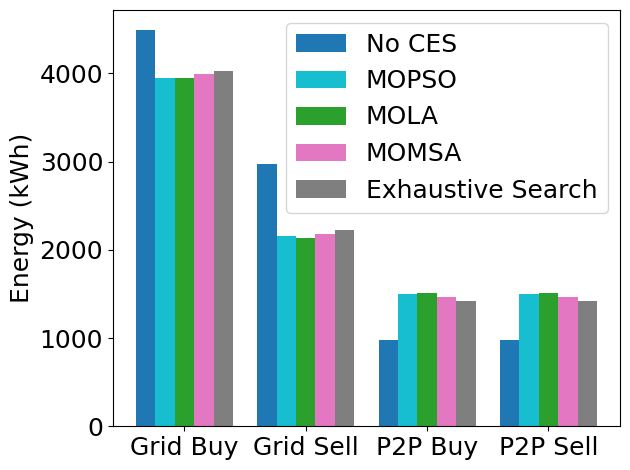

In [61]:
if bus_sys == 33:
    sol_folder = ['no CES', 'MOPSO', 'MOLA', 'MOMSA', 'ES']
else:
    sol_folder = ['no CES', 'MOPSO', 'MOLA', 'MOMSA']

gbuy_total, gsell_total, pbuy_total, psell_total = [], [], [], []
gbuy_total_time, gsell_total_time, pbuy_total_time, psell_total_time = {}, {}, {}, {}

# P2P trading amount breakdown
for i in range(len(sol_folder)):
    gbuy_loc        = fr"{sol_folder[i]}\Grid_buy.csv"
    gsell_loc       = fr"{sol_folder[i]}\Grid_sell.csv"
    pbuy_loc        = fr"{sol_folder[i]}\P2P_buy.csv"
    psell_loc       = fr"{sol_folder[i]}\P2P_sell.csv"

    gbuy_p2p        = pd.read_csv(gbuy_loc, header=0).to_numpy()[:,:-1]
    gsell_p2p       = pd.read_csv(gsell_loc, header=0).to_numpy()[:,:-1]
    pbuy_p2p        = pd.read_csv(pbuy_loc, header=0).to_numpy()[:,:-1]
    psell_p2p       = pd.read_csv(psell_loc, header=0).to_numpy()[:,:-1]

    # Calculate total amounts for each category
    gbuy_total.append(np.sum(gbuy_p2p))
    gsell_total.append(np.sum(gsell_p2p))
    pbuy_total.append(np.sum(pbuy_p2p))
    psell_total.append(np.sum(psell_p2p))

    gbuy_total_time[i], gsell_total_time[i], pbuy_total_time[i], psell_total_time[i] = \
        np.sum(gbuy_p2p, axis=1), np.sum(gsell_p2p, axis=1), np.sum(pbuy_p2p, axis=1), np.sum(psell_p2p, axis=1)

# Set up the bar chart
fig, ax = plt.subplots()

# Set position of bar on X axis
x = np.arange(4)
width = 0.35

# Create bars
# Dynamic width based on number of methods to avoid overlap
n = len(sol_folder)
width = 0.8 / n
offsets = (np.arange(n) - (n - 1) / 2) * width

if bus_sys == 33:
    labels = ['No CES', 'MOPSO', 'MOLA', 'MOMSA', 'Exhaustive Search']
    colors = ["#1f77b4", "#17becf", "#2ca02c", "#e377c2", "#7f7f7f"]
else:
    labels = ['No CES', 'MOPSO', 'MOLA', 'MOMSA']
    colors = ["#1f77b4", "#17becf", "#2ca02c", "#e377c2"]

rects = []
for i in range(n):
    vals = [gbuy_total[i], gsell_total[i], pbuy_total[i], psell_total[i]]
    rect = ax.bar(x + offsets[i], vals, width, label=labels[i] if i < len(labels) else sol_folder[i],
                  color=colors[i] if i < len(colors) else None)
    rects.append(rect)

# Customize the plot
ax.set_ylabel('Energy (kWh)', fontsize=18)
ax.set_xticks(x)
ax.set_xticklabels(['Grid Buy', 'Grid Sell', 'P2P Buy', 'P2P Sell'], fontsize=18)
ax.tick_params(axis='y', labelsize=18)
ax.legend(fontsize=18)

plt.tight_layout()
plt.savefig(r'p2p_comparison.svg', dpi=300, bbox_inches='tight')
plt.show()

# Plot breakdown over time
# fig, ax = plt.subplots(figsize=(10, 6))
# time_hours = np.arange(1, 49) 

# # for i in range(len(sol_folder)):
# for i in range(len(sol_folder)):
#     # ax.plot(time_hours, pbuy_total_time[i], label=f'P2P Buy - {labels[i]}')
#     # ax.plot(time_hours, psell_total_time[i], label=f'P2P Sell - {labels[i]}')
#     # ax.plot(time_hours, gbuy_total_time[i], label=f'Grid Buy - {labels[i]}', linestyle='--')
#     # ax.plot(time_hours, gsell_total_time[i], label=f'Grid Sell - {labels[i]}', linestyle='--')
#     ax.plot(time_hours, pbuy_total_time[i], label=f'P2P Traded - {labels[i]}')
#     # ax.plot(time_hours, psell_total_time[i], label=f'P2P Traded - {labels[i]}')
#     # ax.plot(time_hours, gbuy_total_time[i], label=f'Grid Buy - {labels[i]}', linestyle='--')
#     # ax.plot(time_hours, gsell_total_time[i], label=f'Grid Sell - {labels[i]}', linestyle='--')
# ax.set_xlabel('Time (hours)', fontsize=14)
# ax.set_ylabel('Energy (kWh)', fontsize=14)
# ax.tick_params(axis='y', labelsize=14)
# ax.set_title('P2P Trading Breakdown Over Time', fontsize=16)
# ax.legend(fontsize=10)
# plt.tight_layout()
# plt.savefig(r'Benchmark\p2p_time_breakdown.png', dpi=300, bbox_inches='tight')
# plt.show()

In [23]:
bus_sys = 69
pf_model = "ptdf"

data_folder = rf"D:\Jacky\Data Output\CES size and loc\Individual Scenario Outcome"
os.chdir(data_folder)
os.getcwd()

'D:\\Jacky\\Data Output\\CES size and loc\\Individual Scenario Outcome'

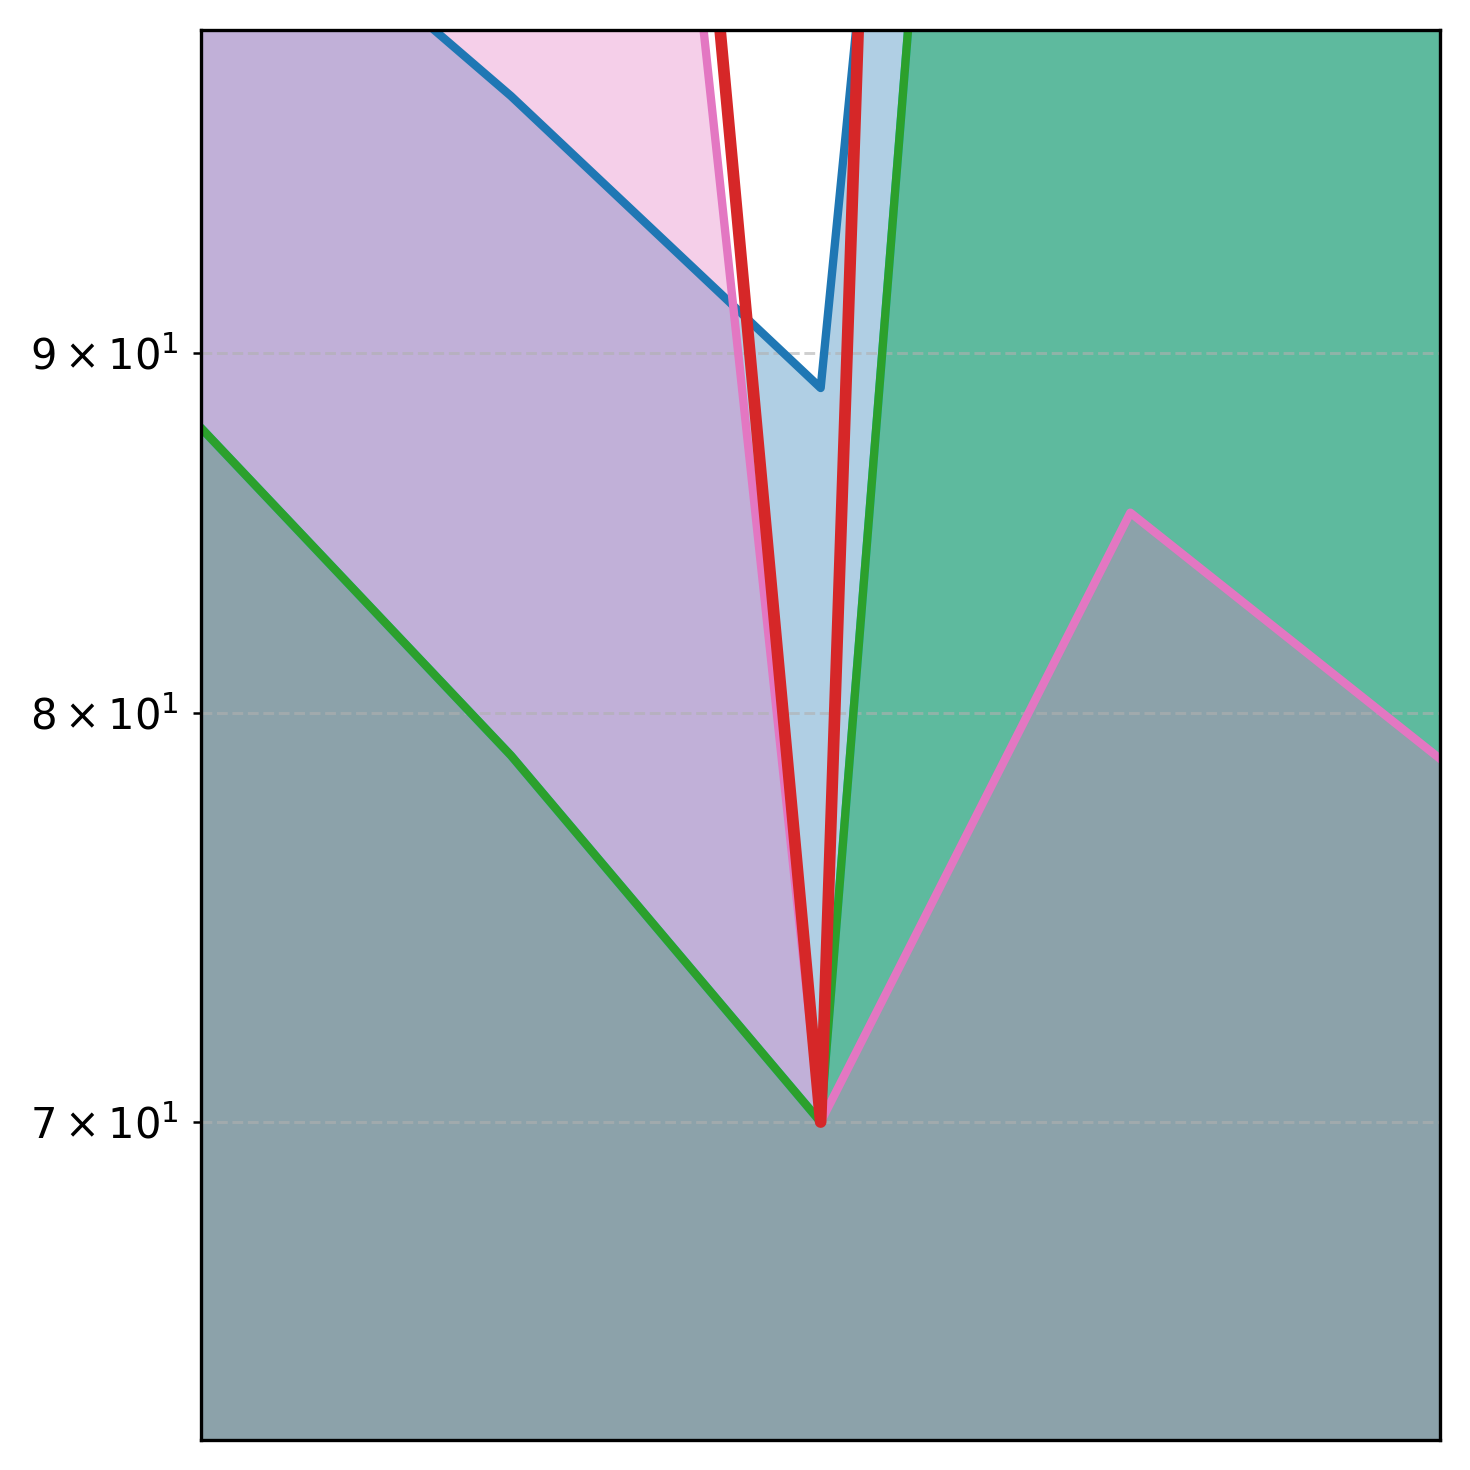

In [59]:
branch_power_loc = 'BranchPowerAll.xlsx'
branch_power = pd.read_excel(branch_power_loc, header=None, sheet_name=f"{bus_sys}bus").to_numpy()
category = branch_power[:, 0]
branch_power = branch_power[:, 1:]

category[0], category[4] = 'no CES', 'Exhaustive Search'

branch_idx = np.arange(1, branch_power.shape[1] + 1)
p_no_ces = branch_power[0, :]
p_mopso = branch_power[1, :]
p_mola = branch_power[2, :]
p_momsa = branch_power[3, :]
p_es = branch_power[4, :]
branch_limit = branch_power[5, :]

colors = {
    "no_ces":   "#1f77b4",  # blue
    "mopso":    "#17becf",  # cyan
    "mola":     "#2ca02c",  # green
    "momsa":    "#e377c2",  # magenta
    "es":       "#7f7f7f",  # grey
    "limit":    "#d62728"   # red
}

branch_idx   = np.asarray(branch_idx, dtype=float).ravel()
p_no_ces     = np.asarray(p_no_ces, dtype=float).ravel()
p_mopso      = np.asarray(p_mopso, dtype=float).ravel()
p_mola       = np.asarray(p_mola, dtype=float).ravel()
p_momsa      = np.asarray(p_momsa, dtype=float).ravel()
p_es         = np.asarray(p_es, dtype=float).ravel()
branch_limit = np.asarray(branch_limit, dtype=float).ravel()

plt.figure(figsize=(5, 5), dpi=300)
# plt.figure(dpi=300)

# Filled curves
plt.fill_between(branch_idx, p_no_ces, color=colors["no_ces"], alpha=0.35, label='no CES')
plt.plot(branch_idx, p_no_ces, color=colors["no_ces"], linewidth=2)

plt.fill_between(branch_idx, p_mopso, color=colors["mopso"], alpha=0.35, label='MOPSO')
plt.plot(branch_idx, p_mopso, color=colors["mopso"], linewidth=2)

plt.fill_between(branch_idx, p_mola, color=colors["mola"], alpha=0.35, label='MOLA')
plt.plot(branch_idx, p_mola, color=colors["mola"], linewidth=2)

plt.fill_between(branch_idx, p_momsa, color=colors["momsa"], alpha=0.35, label='MOMSA')
plt.plot(branch_idx, p_momsa, color=colors["momsa"], linewidth=2)

if bus_sys == 33:
    plt.fill_between(branch_idx, p_es, color=colors["es"], alpha=0.35, label='Exhaustive Search')
    plt.plot(branch_idx, p_es, color=colors["es"], linewidth=2)
    
plt.plot(branch_idx, branch_limit, color=colors["limit"], linewidth=2.8, label='Branch Limit')

# ----------------------------
# Axis formatting
# ----------------------------
plt.yscale('log')
# plt.xlabel('Branch', fontsize=18)
# plt.ylabel('Log-scaled Power Flow (kW)', fontsize=18)
plt.xticks([])
plt.yticks([])
plt.xlim(left=32,right=36)
plt.ylim(bottom=10**1.8, top=10**2)
# plt.title('Power Exchange Profile ', fontsize=18)

plt.grid(True, which='both', linestyle='--', linewidth=0.7, alpha=0.6)
# plt.legend(loc='upper right', fontsize=12)

plt.tight_layout()
# plt.savefig(f"power_exchange_profile_{bus_sys}bus.svg")
plt.savefig(f"power_exchange_profile_zoom2_{bus_sys}bus.svg")
plt.show()